In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import skimage
import copy

import scipy
from scipy.stats import linregress, spearmanr
import seaborn as sns
from matplotlib.markers import MarkerStyle
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
from watermark import watermark
print(watermark())
print(watermark(packages="pandas,numpy,matplotlib,skimage,scipy,seaborn"))

Last updated: 2026-05-06T14:32:37.776893-07:00

Python implementation: CPython
Python version       : 3.13.9
IPython version      : 9.6.0

Compiler    : MSC v.1944 64 bit (AMD64)
OS          : Windows
Release     : 10
Machine     : AMD64
Processor   : Intel64 Family 6 Model 63 Stepping 2, GenuineIntel
CPU cores   : 72
Architecture: 64bit

pandas    : 2.2.3
numpy     : 2.1.2
matplotlib: 3.10.7
skimage   : 0.25.2
scipy     : 1.14.1
seaborn   : 0.13.2



In [2]:
new_smFISH_cnts = pd.read_csv("smFISH_gene_by_cell_cnts.csv")
new_smFISH_cnts.set_index("cell id", inplace=True)

In [3]:
new_smFISH_cnts

,acly,aebp1,aldh18a1,axl,btg1,col1a1,col1a2,col6a1,ctdsp2,ctsb,...,scd2,serbp1,srebf2,stt3a,thbs1,thbs2,tnc,top2a,trps1,xdh
cell id,,,,,,,,,,,,,,,,,,,,,
cell_10_Pos13_z4,56,174,33,212,83,295,207,70,66,214,...,103,14,58,51,31,121,83,15,37,35
cell_10_Pos16_z4,50,81,17,117,47,123,133,18,38,132,...,78,10,33,21,16,46,19,15,15,36
cell_10_Pos1_z4,63,73,29,195,56,339,288,102,84,250,...,134,29,62,59,48,43,91,25,29,13
cell_10_Pos31_z4,61,139,58,226,98,293,275,125,94,257,...,116,23,55,54,131,124,67,38,64,54
cell_10_Pos33_z4,158,254,99,399,39,630,635,98,120,623,...,224,13,99,93,39,129,161,359,38,55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cell_9_Pos28_z4,123,177,67,283,35,508,521,140,91,463,...,173,13,81,78,64,101,83,190,43,116
cell_9_Pos2_z4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
cell_9_Pos31_z4,170,151,62,252,47,414,400,73,55,341,...,175,30,69,106,90,31,130,133,37,13


In [4]:
new_smFISH_cnts.mean()

acly        100.238532
aebp1       168.756881
aldh18a1     71.610092
axl         268.266055
btg1         73.302752
col1a1      385.545872
col1a2      353.866972
col6a1       95.183486
ctdsp2       88.013761
ctsb        325.000000
ddb1        314.545872
eif3a       213.793578
eif4g1      224.839450
eif4g2      293.009174
fbln2       295.715596
flna        219.339450
fn1         513.059633
fstl1        50.931193
ganab        79.371560
grb10       295.623853
hdlbp       177.192661
ipo5        121.903670
kpnb1       310.600917
ltbp3        77.018349
malat1      296.068807
mrpl17       30.811927
mybbp1a     369.422018
myh9        263.165138
naca         15.802752
ncl         212.371560
nedd4       247.802752
prrc2a      241.619266
ptgs2       102.146789
rps15a       11.270642
rps6ka3      58.027523
rps6ka5      11.788991
rps6kc1      12.770642
sars         66.091743
scd1         49.701835
scd2        146.931193
serbp1       26.293578
srebf2       82.096330
stt3a        72.577982
thbs1      

# Find summary for decoding with the parameter set chosen in the text

In [5]:
least_stringent_counts = pd.read_csv("cell_x_gene_mats/lf_ 2.0_dr_1_cnts.csv")
least_stringent_counts.set_index(["pos", "cellid"], inplace=True)
least_stringent_counts.fillna(0, inplace=True)

In [6]:
text_chosen_stringency_counts = pd.read_csv("cell_x_gene_mats/lf_ 3.0_dr_1_cnts.csv")
text_chosen_stringency_counts.set_index(["pos", "cellid"], inplace=True)

In [7]:
ncells = len(text_chosen_stringency_counts)
ncells

217

In [8]:
cell_n_barcodes = text_chosen_stringency_counts.sum(axis=1)#.loc[:, "count"]

In [9]:
gene_n_barcodes = text_chosen_stringency_counts.mean(axis=0)

In [10]:
mean_sf_ngcnts = np.sort(gene_n_barcodes)

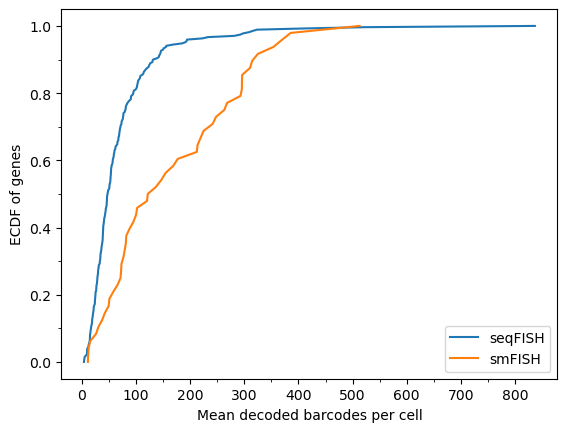

In [11]:
plt.plot(mean_sf_ngcnts, np.linspace(0, 1, len(mean_sf_ngcnts)), label="seqFISH")
plt.plot(np.sort(new_smFISH_cnts.mean()), np.linspace(0, 1, len(new_smFISH_cnts.mean())), label=r"smFISH")
plt.xlabel("Mean decoded barcodes per cell")
plt.ylabel("ECDF of genes")
plt.xticks([0,100,200,300,400,500,600,700,800])
plt.xticks([50,150,250,350,450,550,650,750],minor=True)
plt.yticks([0.1, 0.3, 0.5, 0.7, 0.9], minor=True)
plt.legend()
plt.savefig("SFig2B_seqFISH_smFISH_gene_expression_ECDF.pdf")

In [12]:
len(mean_sf_ngcnts)

271

## Get text reported statistics on the distribution of number of barcodes found in cell

In [13]:
ncells = 0
npixels = 0
cell_name = []
cell_pixels = []
for labeled_img_file_name in os.listdir("../../real_data_processing_workflows/Reed-Solomon_encoded_experiment_workflow/resources/labeled_images"):
    lbled_img = skimage.io.imread("../../real_data_processing_workflows/Reed-Solomon_encoded_experiment_workflow/resources/labeled_images/" + labeled_img_file_name)
    img_copy = copy.deepcopy(lbled_img)
    img_copy[1:2046, 1:2046] = 0
    edge_regions = np.unique(img_copy)
    
    for reg in edge_regions:
        lbled_img[lbled_img == reg] = 0
    regions = np.unique(lbled_img)
    cells = regions[regions != 0]
    #print(cells)
    ncells += len(cells)
    npixels += np.sum(lbled_img != 0)

Average number of barcodes per micron of cell mask reported in text:

In [14]:
least_stringent_counts.sum().sum()/((0.103**2)*npixels)

np.float64(12.802900781820304)

Mean decoded gene encoding barcodes per cell reported in text:

In [15]:
np.mean(cell_n_barcodes)

np.float64(18903.05069124424)

Standard deviation of gene encoding barcodes decoded per cell reported in text:

In [16]:
np.std(cell_n_barcodes, ddof=1)

np.float64(7571.785157082251)

### Plot the distibrution of the numbers of barcodes found in each cell

Text(0.5, 1.0, 'Distribution of Barcode Counts in Cells')

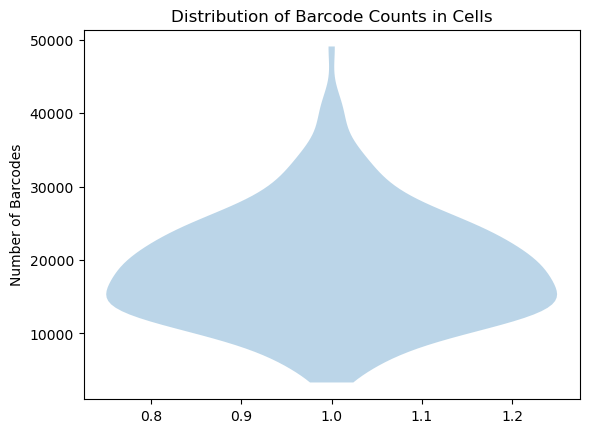

In [17]:
plt.violinplot(cell_n_barcodes, showextrema=False)
plt.ylabel("Number of Barcodes")
plt.title("Distribution of Barcode Counts in Cells")

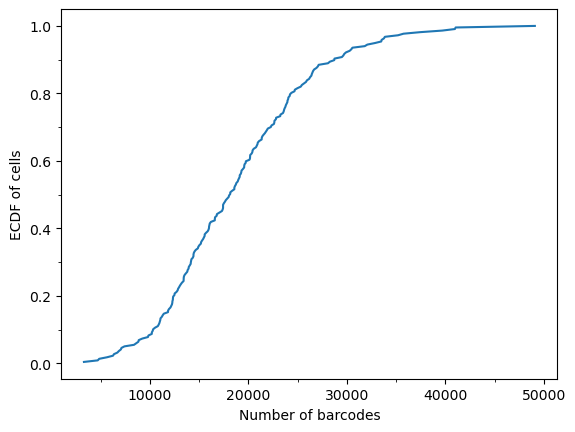

In [18]:
plt.plot(np.sort(cell_n_barcodes), np.array(range(1, 1+ len(cell_n_barcodes)))/len(cell_n_barcodes))
plt.xlabel("Number of barcodes")
plt.ylabel("ECDF of cells")
plt.yticks([0.1, 0.3, 0.5, 0.7, 0.9], minor=True)
plt.xticks([5000, 15000, 25000, 35000, 45000], minor=True)
plt.savefig("SFig2A.pdf")

## Make regression plot of least stringent seqFISH vs smFISH

In [19]:
text_chosen_stringency_counts

aars  aco2  actn4  aebp1  aqp1  arf1  arpc2  arpc5  cct3  cct5  \
pos cellid                                                                   
0   1         28    14     78    151    23    75     45     12    30   112   
    2         25    11    106    120    11    72     55     26    57    89   
    3         31    21    120    147    12   136     88     33   109   146   
    4         24    28     92     69    10    99     43     12    62   136   
    5         16    17     48     59     5    40     35     14    34    82   
...          ...   ...    ...    ...   ...   ...    ...    ...   ...   ...   
29  8         97    55    306    155    30   249    177     95   195   207   
30  1         95    53    234    150    29   201     76     47   108   158   
    2         66    31    153    102    21   117     77     33    68    89   
    6         46    30    155    137    25    78     79     35    78    94   
    8         56    32    300    190    39   134    112     49   104   160   

            ...  xdh  ybx1  ywhae  ywhag  ywhah  ywhaq  ywhaz  zfp36l1  \
pos cellid  ...                                                          
0   1       ...   62   169   21.0     40     35     22     85       92   
    2       ...   58   174   15.0     79     54     41     45       31   
    3       ...   85   292   15.0    114     74     84     82       44   
    4       ...   41   194   26.0     60     44     43     41       60   
    5       ...   48    79    7.0     39     31     31     49       22   
...         ...  ...   ...    ...    ...    ...    ...    ...      ...   
29  8       ...   70   702   42.0    179     99    148    164       43   
30  1       ...  102   566   36.0    170     72    122    103       31   
    2       ...   58   334   23.0     66     52     61     68       46   
    6       ...   64   316   19.0     78     51     59     79       42   
    8       ...   68   469   39.0     81    131     98     99       49   

            zfp36l2  zyx  
pos cellid                
0   1            82   42  
    2            53  154  
    3            76  306  
    4            82  161  
    5            65   61  
...             ...  ...  
29  8           144  302  
30  1           179  412  
    2           124  234  
    6           148  208  
    8           188  364  

[217 rows x 271 columns]

In [20]:
seqFISH_new_gene_avg = text_chosen_stringency_counts.sum()/ncells
seqFISH_new_gene_avg.index = [gn.lower() for gn in seqFISH_new_gene_avg.index]
seqFISH_new_gene_avg.name = 'seqFISH'
comp_df = pd.DataFrame(seqFISH_new_gene_avg)
comp_df['smFISH'] = new_smFISH_cnts.mean()
comp_df.dropna(inplace=True)

In [21]:
comp_df

,seqFISH,smFISH
aebp1,125.187215,168.756881
ctsb,89.908676,325.000000
eif3a,37.045662,213.793578
eif4g2,130.657534,293.009174
fbln2,106.292237,295.715596
ltbp3,25.237443,77.018349
malat1,278.598174,296.068807
mrpl17,21.273973,30.811927
myh9,154.570776,263.165138
naca,15.114155,15.802752


### Remove outlier
rps15a is an outlier in that the number of transcripts detected for this gene by smFISH was much lower than expected given the number of of transcripts detected by seqFISH. Inspection of the smFISH images showed that the rps15a smFISH images were much dimmer than the smFISH images for other genes, so we remove rps15a from the analysis.

In [22]:
comp_df = comp_df.loc[comp_df.index != 'rps15a']

In [23]:
comp_df

,seqFISH,smFISH
aebp1,125.187215,168.756881
ctsb,89.908676,325.000000
eif3a,37.045662,213.793578
eif4g2,130.657534,293.009174
fbln2,106.292237,295.715596
ltbp3,25.237443,77.018349
malat1,278.598174,296.068807
mrpl17,21.273973,30.811927
myh9,154.570776,263.165138
naca,15.114155,15.802752


In [24]:
lm = linregress(comp_df.smFISH, comp_df.seqFISH)
lm

LinregressResult(slope=np.float64(0.49005889962089016), intercept=np.float64(5.712498557346663), rvalue=np.float64(0.7041983817421446), pvalue=np.float64(0.0003664386606424867), stderr=np.float64(0.11335398810592576), intercept_stderr=np.float64(21.415837229427805))

In [25]:
spear_r = spearmanr(comp_df.smFISH, comp_df.seqFISH)
spear_r

SignificanceResult(statistic=np.float64(0.7753246753246753), pvalue=np.float64(3.6511080075003137e-05))

In [26]:
spear_r[0]

np.float64(0.7753246753246753)

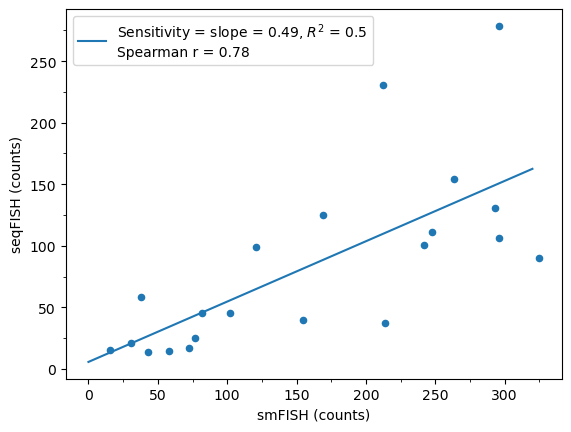

In [27]:
comp_df.plot('smFISH', 'seqFISH','scatter')
plt.plot([0,320], [lm.intercept,320 * lm.slope + lm.intercept], label = "Sensitivity = slope = " + str(np.round(lm.slope,2)) + r", $R^2$ = " + str(np.round(lm.rvalue**2,2)) + '\nSpearman r = ' + str(np.round(spear_r[0],2)))
#plt.title("Average counts of various genes across cells")
plt.xlabel("smFISH (counts)")
plt.xticks([25,75,125,175,225,275,325], minor=True)
plt.ylabel("seqFISH (counts)")
plt.yticks([25,75,125,175,225,275], minor=True)
plt.legend()
plt.savefig("Fig2E_sens_fit.pdf")

# Compare decoding performance with each set of decoding parameters

lf:  2.0
lf:  2.5
lf:  3.0
lf:  3.5
lf:  4.0
lf:  4.5
lf:  5.0
lf:  5.5
lf:  6.0
lf:  6.5
lf:  7.0


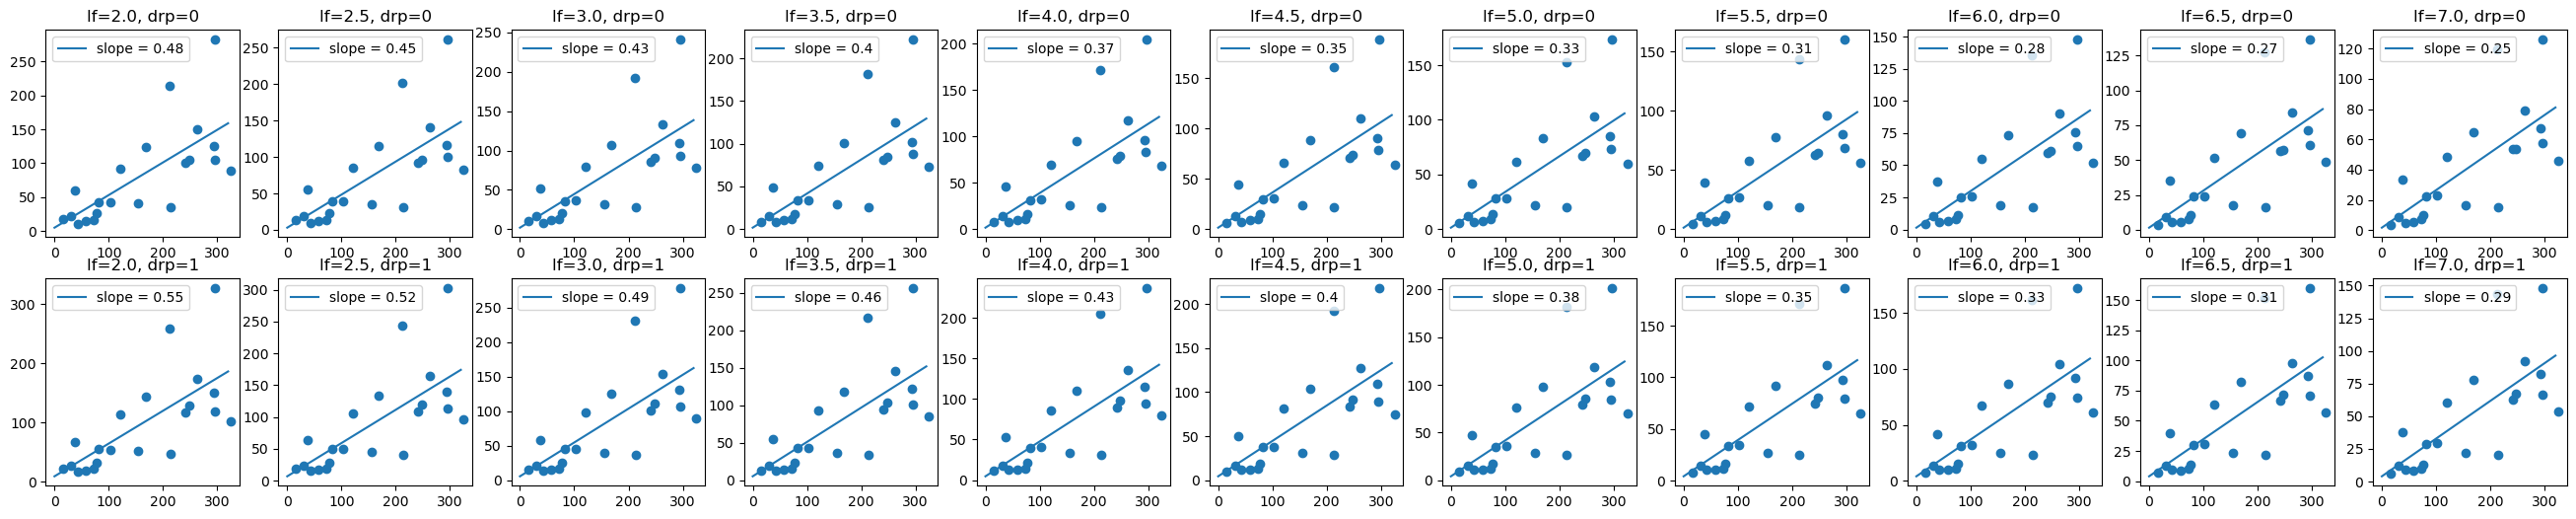

In [28]:
lfs= []
drps = []
ms = []

fig, ax = plt.subplots(2,11, figsize=(33,6))
for i, lf in enumerate(["2.0", '2.5', "3.0", '3.5','4.0','4.5', "5.0",'5.5','6.0','6.5',"7.0"]):

    print("lf: ", lf)
    for j, drp in enumerate(['0','1']):
        lf_cell_gene_cnts = pd.read_csv("cell_x_gene_mats/lf_ " + lf + "_dr_" + drp + "_cnts.csv")
        seqFISH_prms_gene_avg = lf_cell_gene_cnts.sum()/ncells
        
        seqFISH_prms_gene_avg.name = 'seqFISH'

        prms_comp_df = pd.DataFrame(seqFISH_prms_gene_avg)
        prms_comp_df['smFISH'] = new_smFISH_cnts.mean()

        prms_comp_df.dropna(inplace=True)

        # remove outlier gene that was poorly detected by smFISH
        prms_comp_df = prms_comp_df.loc[prms_comp_df.index != 'rps15a']
        

        lm = linregress(prms_comp_df.smFISH, prms_comp_df.seqFISH)
        lfs.append(float(lf))
        drps.append(int(drp))
        ms.append(lm.slope)
        ax[j,i].scatter(prms_comp_df.smFISH, prms_comp_df.seqFISH)
        ax[j,i].plot([0,320], [lm.intercept,320 * lm.slope + lm.intercept], label = "slope = " + str(np.round(lm.slope,2)))
        ax[j,i].legend()
        ax[j,i].set_title(f"lf={lf}, drp={drp}")

In [29]:
sens = pd.DataFrame({"lvf":lfs, "dr" :drps, "sen": ms})
sens.set_index(["lvf","dr"], inplace=True)

In [30]:
ss = pd.read_csv('decode_summary_stats.csv')


prms_ss_summed = ss.groupby(['lvf', 'dr']).sum()
prms_ss_summed['est_FDR'] = 271*(prms_ss_summed['negative_control_barcodes']/(2100-271))/prms_ss_summed['gene_encoding_barcodes']
prms_ss_summed['sen'] = sens

In [31]:
tick_width = 2
tick_length = 8
title_size=50
axis_label_size = 30
tick_label_size = 21
Panel_letter_size = 60
legend_font_size=9
marker_size_min = 100
marker_size_max = 600

prms_ss_summed.reset_index(inplace=True)


prms_ss_summed.loc[:, "Position\nvariance\npenalty"] = np.int64(prms_ss_summed["lvf"])
prms_ss_summed.loc[:, "Position variance\npenalty"] = np.int64(prms_ss_summed["lvf"])
prms_ss_summed.loc[:, "Position variance penalty"] = np.int64(prms_ss_summed["lvf"])


prms_ss_summed.loc[:, "Drops\nallowed"] = prms_ss_summed["dr"]
prms_ss_summed.loc[:, "Drops allowed"] = prms_ss_summed["dr"]

prms_ss_summed.loc[:, "Sensitivity"] = prms_ss_summed["sen"]
prms_ss_summed.loc[:, "Estimated FDR"] = prms_ss_summed["est_FDR"]
prms_ss_summed.loc[:, "Estimated PPV"] = 1 - prms_ss_summed["est_FDR"]

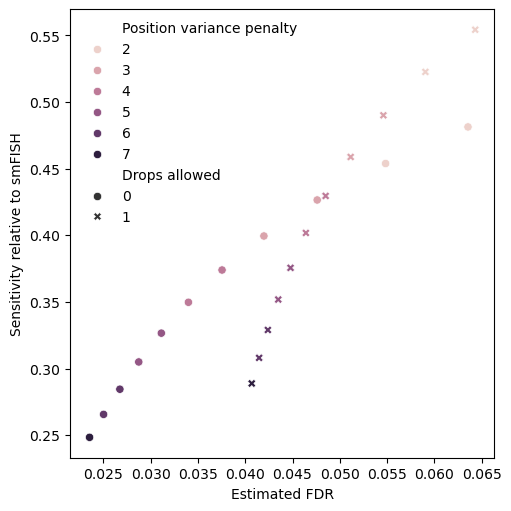

In [32]:
fig, axes = plt.subplots(1,1, figsize=(5,5), layout="constrained")
sns.scatterplot(ax=axes,data=prms_ss_summed, x= "Estimated FDR", y= 'Sensitivity', hue="Position variance penalty", style="Drops allowed",legend=True)
#plt.title("Decoding Performance with different parameters")
#axes.legend(frameon=False, bbox_to_anchor=[1, 1], loc="upper left")
axes.legend(frameon=False, loc="upper left")

plt.xlabel("Estimated FDR")
plt.ylabel("Sensitivity relative to smFISH")
plt.savefig("fig2B.pdf")

In [33]:
prms_ss_summed.loc[:, ["lvf", "dr", "Sensitivity", "Estimated FDR"]]

,lvf,dr,Sensitivity,Estimated FDR
0,2.0,0,0.481314,0.063547
1,2.0,1,0.554242,0.064310
2,2.5,0,0.453874,0.054837
3,2.5,1,0.522587,0.059045
4,3.0,0,0.426521,0.047606
5,3.0,1,0.490059,0.054603
6,3.5,0,0.399501,0.041972
7,3.5,1,0.458792,0.051142
8,4.0,0,0.373991,0.037547
9,4.0,1,0.429562,0.048496
